In [2]:
import cv2 
import IPython
import numpy as np
import pandas as pd

# from qdrant_client import QdrantClient 
# from qdrant_client.models import Distance, VectorParams, PointStruct

In [3]:
# CLIENT = QdrantClient(host='192.168.0.131', port=6333)   

In [4]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [5]:
def image_from_video(row):
    cap = cv2.VideoCapture(row['filepath'])
    cap.set(cv2.CAP_PROP_POS_FRAMES, row['frame_num'])
    ret, frame = cap.read()
    h, w = (row['img_height'], row['img_width'])
    cv2.rectangle(frame, (int(row['x1'] * w), int(row['y1'] * h)), 
                         (int(row['x2'] * w), int(row['y2'] * h)), (0, 0, 255), 3)
    show_image(frame)

In [6]:
def parse_vector(vector):
    return np.array([float(x) for x in vector.split('\n')])

In [8]:
src = '../../data/faces/for-all-mankind_2019_7772588/For.All.Mankind.S03E10.1080p.WEBRip.x265-RARBG.csv'
df = pd.read_csv(src, index_col=0)
df.head()

,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,frame_num,img_width,img_height,filepath,encoding,series_id,episode_id,filename,distance_from_center,pct_of_frame
0,0.241,0.112,0.558,0.938,0.358,0.390,0.496,0.444,0.430,0.598,...,432,1920,960,/home/amos/media/tv/For.All.Mankind.S01-S03.10...,-0.119807\n0.115922\n0.039224\n0.036903\n-0.07...,7772588,NaN,For.All.Mankind.S03E10.1080p.WEBRip.x265-RARBG...,194.49,26.12
1,0.328,0.176,0.641,0.998,0.447,0.477,0.583,0.510,0.524,0.690,...,456,1920,960,/home/amos/media/tv/For.All.Mankind.S01-S03.10...,-0.114525\n0.112782\n0.0280279\n-0.00757489\n-...,7772588,NaN,For.All.Mankind.S03E10.1080p.WEBRip.x265-RARBG...,88.26,25.68
2,0.260,0.120,0.584,0.991,0.398,0.413,0.534,0.459,0.485,0.620,...,504,1920,960,/home/amos/media/tv/For.All.Mankind.S01-S03.10...,-0.0558497\n0.0902229\n0.0016422\n0.0141423\n-...,7772588,NaN,For.All.Mankind.S03E10.1080p.WEBRip.x265-RARBG...,159.09,28.21
3,0.338,0.051,0.672,0.922,0.483,0.344,0.621,0.425,0.561,0.558,...,528,1920,960,/home/amos/media/tv/For.All.Mankind.S01-S03.10...,-0.0780547\n0.0999012\n0.00648193\n-0.0144452\...,7772588,NaN,For.All.Mankind.S03E10.1080p.WEBRip.x265-RARBG...,15.81,29.07
4,0.355,0.156,0.543,0.712,0.392,0.367,0.478,0.377,0.418,0.491,...,576,1920,960,/home/amos/media/tv/For.All.Mankind.S01-S03.10...,-0.0500331\n0.0732977\n0.103114\n0.0242911\n-0...,7772588,NaN,For.All.Mankind.S03E10.1080p.WEBRip.x265-RARBG...,117.05,10.41


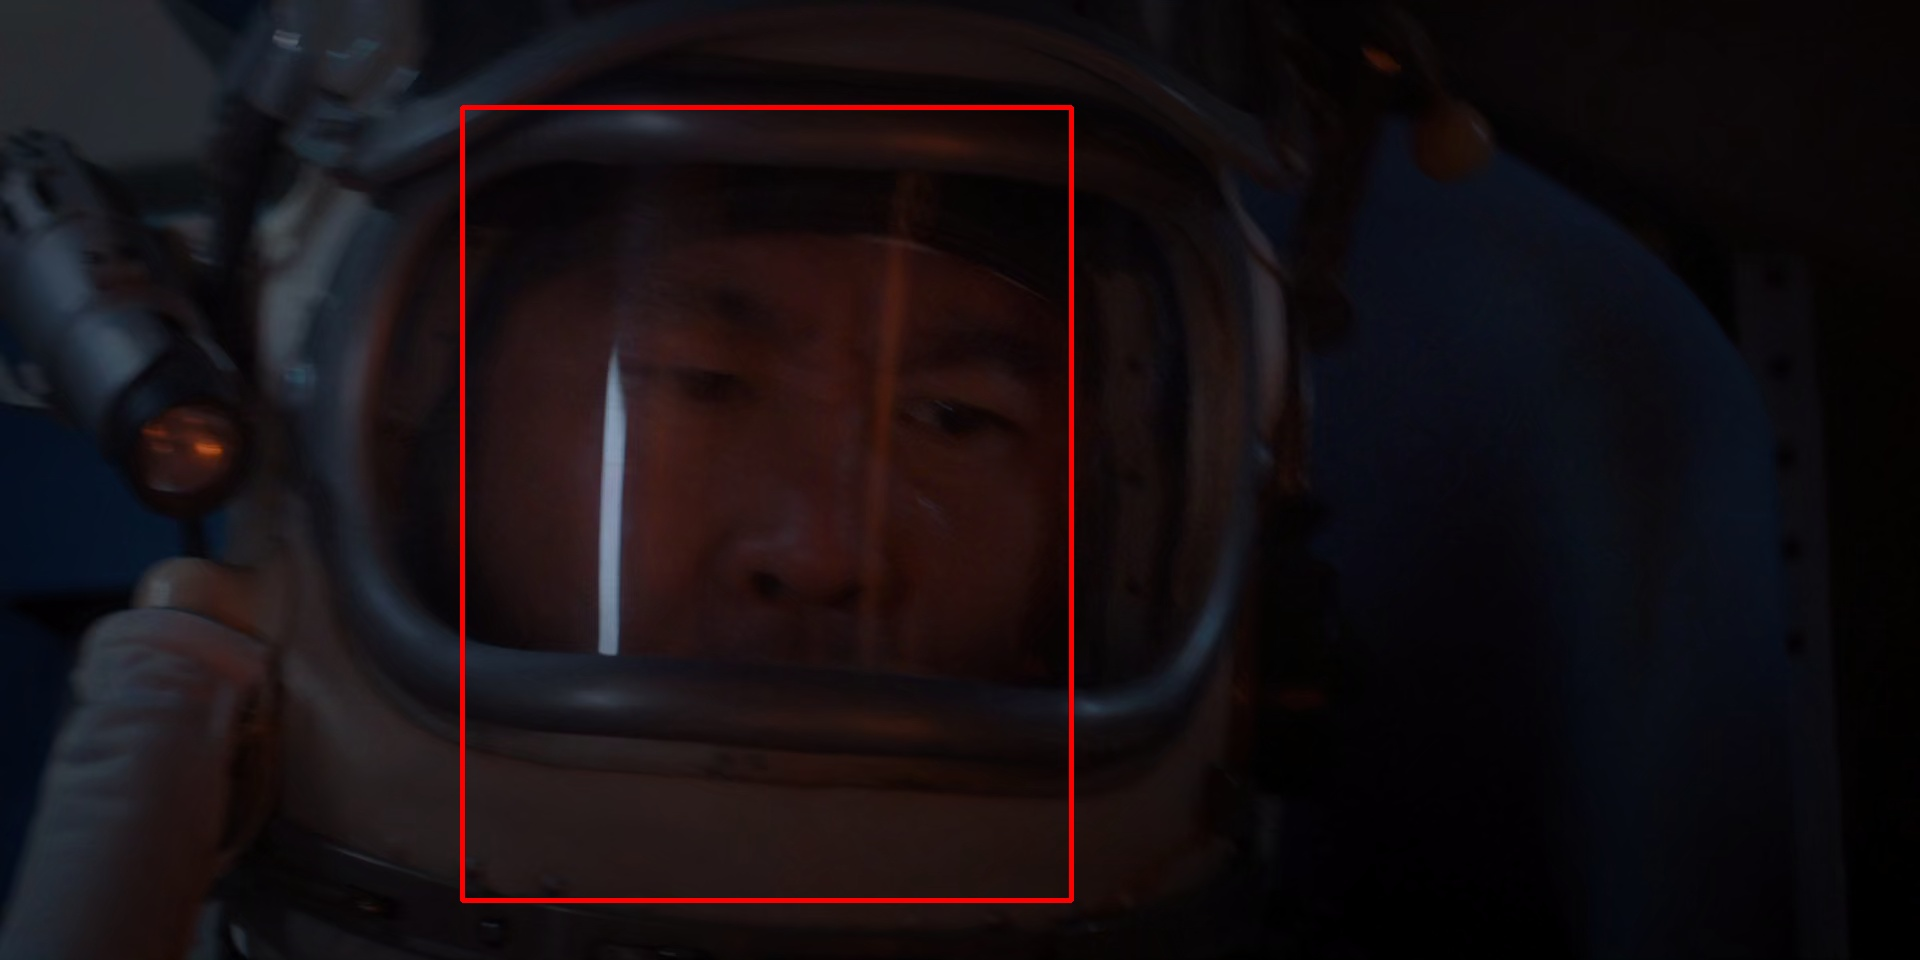

In [9]:
image_from_video(df.iloc[0])